# Coffee Roast Level Classifier
## Ethiopian Coffee Quality Predictor — Model 2

This notebook trains a CNN (MobileNetV2 transfer learning) to classify
coffee bean roast levels from photos: green, light, medium, dark.
The trained model is exported as an .h5 file for FastAPI serving.

## CELL 1 — Imports

Import TensorFlow/Keras, kagglehub, and utilities.

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint
import  kagglehub,json, os
import matplotlib.pyplot as plt

I0000 00:00:1782044137.794938   48948 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782044138.306552   48948 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782044141.676900   48948 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## CELL 2 — Load dataset

Load the local coffee bean image dataset from 'roast  data sets' and inspect
the folder structure.

In [2]:
path = kagglehub.dataset_download("gpiosenka/coffee-bean-dataset-resized-224-x-224")

train_path = os.path.join(path, "train")
test_path = os.path.join(path, "test")


## CELL 3 — Image data generators

Create training and validation generators with augmentation
for the training split.

In [3]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path, target_size=(224,224),
    batch_size=32, class_mode='categorical')

val_data = val_gen.flow_from_directory(
    test_path, target_size=(224,224),
    batch_size=32, class_mode='categorical', shuffle=False)

print("Classes found:", train_data.class_indices)

Found 1200 images belonging to 4 classes.
Found 400 images belonging to 4 classes.
Classes found: {'Dark': 0, 'Green': 1, 'Light': 2, 'Medium': 3}


## CELL 4 — Build transfer learning model

Use MobileNetV2 pre-trained on ImageNet as the backbone.
Freeze the backbone and train only the new top layers.

In [4]:
base = MobileNetV2(input_shape=(224,224,3),
                   include_top=False, weights='imagenet')
base.trainable = False 

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(4, activation='softmax')(x)   

roast_model = Model(inputs=base.input, outputs=output)
roast_model.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])
roast_model.summary()

E0000 00:00:1782044148.328752   48948 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## CELL 5 — Train model

Train for 10 epochs with a ModelCheckpoint saving the best
validation accuracy weights.

In [5]:
checkpoint = ModelCheckpoint(
    'outputs/models/roast_classifier.h5',
    monitor='val_accuracy', save_best_only=True, verbose=1)
history = roast_model.fit(
    train_data, validation_data=val_data,
    epochs=10, callbacks=[checkpoint])

Epoch 1/10


I0000 00:00:1782044151.877616   48948 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
W0000 00:00:1782044159.038126   56958 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.
W0000 00:00:1782044159.156065   56958 cpu_allocator_impl.cc:82] Allocation of 51380224 exceeds 10% of free system memory.
W0000 00:00:1782044159.286975   56958 cpu_allocator_impl.cc:82] Allocation of 154140672 exceeds 10% of free system memory.
W0000 00:00:1782044159.449379   56958 cpu_allocator_impl.cc:82] Allocation of 156905472 exceeds 10% of free system memory.
W0000 00:00:1782044159.822599   56958 cpu_allocator_impl.cc:82] Allocation of 38535168 exceeds 10% of free system memory.


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6220 - loss: 0.9982
Epoch 1: val_accuracy improved from None to 0.97750, saving model to outputs/models/roast_classifier.h5



Epoch 1: finished saving model to outputs/models/roast_classifier.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 123s 3s/step - accuracy: 0.8125 - loss: 0.5316 - val_accuracy: 0.9775 - val_loss: 0.1014
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9770 - loss: 0.0964
Epoch 2: val_accuracy did not improve from 0.97750
38/38 ━━━━━━━━━━━━━━━━━━━━ 165s 4s/step - accuracy: 0.9667 - loss: 0.1107 - val_accuracy: 0.9775 - val_loss: 0.0738
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9811 - loss: 0.0720
Epoch 3: val_accuracy improved from 0.97750 to 0.98500, saving model to outputs/models/roast_classifier.h5



Epoch 3: finished saving model to outputs/models/roast_classifier.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 136s 4s/step - accuracy: 0.9783 - loss: 0.0756 - val_accuracy: 0.9850 - val_loss: 0.0496
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9777 - loss: 0.0635
Epoch 4: val_accuracy did not improve from 0.98500
38/38 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.9825 - loss: 0.0585 - val_accuracy: 0.9775 - val_loss: 0.0660
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9915 - loss: 0.0480
Epoch 5: val_accuracy improved from 0.98500 to 0.99500, saving model to outputs/models/roast_classifier.h5



Epoch 5: finished saving model to outputs/models/roast_classifier.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.9858 - loss: 0.0533 - val_accuracy: 0.9950 - val_loss: 0.0218
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9945 - loss: 0.0280
Epoch 6: val_accuracy did not improve from 0.99500
38/38 ━━━━━━━━━━━━━━━━━━━━ 111s 3s/step - accuracy: 0.9925 - loss: 0.0352 - val_accuracy: 0.9925 - val_loss: 0.0303
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9905 - loss: 0.0329
Epoch 7: val_accuracy did not improve from 0.99500
38/38 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.9900 - loss: 0.0335 - val_accuracy: 0.9925 - val_loss: 0.0319
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9896 - loss: 0.0354
Epoch 8: val_accuracy improved from 0.99500 to 1.00000, saving model to outputs/models/roast_classifier.h5



Epoch 8: finished saving model to outputs/models/roast_classifier.h5
38/38 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.9883 - loss: 0.0357 - val_accuracy: 1.0000 - val_loss: 0.0154
Epoch 9/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9941 - loss: 0.0309
Epoch 9: val_accuracy did not improve from 1.00000
38/38 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.9908 - loss: 0.0346 - val_accuracy: 0.9975 - val_loss: 0.0263
Epoch 10/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9881 - loss: 0.0321
Epoch 10: val_accuracy did not improve from 1.00000
38/38 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.9908 - loss: 0.0261 - val_accuracy: 0.9950 - val_loss: 0.0174


## CELL 6 — Evaluate and plot accuracy

Plot training and validation accuracy curves.

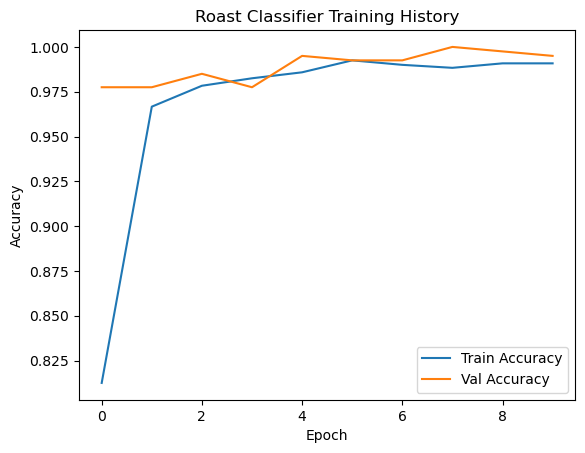

In [6]:
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Roast Classifier Training History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig('outputs/charts/roast_training.png')
plt.show()

## CELL 7 — Predict on a new image (standalone example)

Load the saved .h5 model and run inference on a single image.
This mirrors what FastAPI will do at runtime.

In [7]:
import numpy as np
from tensorflow.keras.preprocessing import image

sample_class = 'Dark'  
sample_dir = os.path.join(test_path, sample_class)
sample_file = os.listdir(sample_dir)[0]
sample_img_path = os.path.join(sample_dir, sample_file)
print("Using:", sample_img_path)

img = image.load_img(sample_img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

roast_model_loaded = tf.keras.models.load_model('outputs/models/roast_classifier.h5')
pred = roast_model_loaded.predict(img_array)

# Use the actual class mapping from training, not a hardcoded guess
class_names = {v: k for k, v in train_data.class_indices.items()}
predicted_idx = np.argmax(pred)
print(f'Roast Level: {class_names[predicted_idx]}')
print(f'Confidence: {pred[0][predicted_idx]*100:.1f}%')

Using: /home/natnael/.cache/kagglehub/datasets/gpiosenka/coffee-bean-dataset-resized-224-x-224/versions/1/test/Dark/dark (13).png


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Roast Level: Dark
Confidence: 100.0%


## CELL 8 — Export class labels

Save the class index mapping so FastAPI can decode predictions.

In [8]:
with open('outputs/models/roast_classes.json', 'w') as f:
    json.dump(list(train_data.class_indices.keys()), f)
print("Saved roast_classes.json")

Saved roast_classes.json


## CELL 9 - SAVE THE RESULT IN resultsmodel2.txt

In [9]:
import numpy as np

lines = []
def w(text=""):
    lines.append(str(text))

w("="*60)
w("MODEL 2: ROAST LEVEL CLASSIFIER (MobileNetV2 Transfer Learning)")
w("="*60)
w(f"Dataset source: kagglehub - gpiosenka/coffee-bean-dataset-resized-224-x-224")
w(f"Classes found: {train_data.class_indices}")
w(f"Number of classes: {len(train_data.class_indices)}")
w(f"Training images: {train_data.samples}")
w(f"Validation/test images: {val_data.samples}")
w(f"Image size: 224x224x3")
w(f"Batch size: 32")
w(f"Epochs trained: {len(history.history['accuracy'])}")

w("")
w("ARCHITECTURE")
w("-"*60)
w("Base: MobileNetV2 (pretrained on ImageNet, frozen)")
w("Head: GlobalAveragePooling2D -> Dense(128, relu) -> Dense(4, softmax)")
w("Optimizer: Adam | Loss: categorical_crossentropy")

w("")
w("TRAINING HISTORY (per epoch)")
w("-"*60)
w(f"{'Epoch':<8}{'Train Acc':<12}{'Val Acc':<12}{'Train Loss':<12}{'Val Loss':<12}")
for i in range(len(history.history['accuracy'])):
    w(f"{i+1:<8}{history.history['accuracy'][i]:<12.4f}"
      f"{history.history['val_accuracy'][i]:<12.4f}"
      f"{history.history['loss'][i]:<12.4f}"
      f"{history.history['val_loss'][i]:<12.4f}")

w("")
w("FINAL / BEST RESULTS")
w("-"*60)
best_epoch = int(np.argmax(history.history['val_accuracy']))
w(f"Best Val Accuracy: {max(history.history['val_accuracy']):.4f} (epoch {best_epoch+1})")
w(f"Final Train Accuracy: {history.history['accuracy'][-1]:.4f}")
w(f"Final Val Accuracy: {history.history['val_accuracy'][-1]:.4f}")
w(f"Final Train Loss: {history.history['loss'][-1]:.4f}")
w(f"Final Val Loss: {history.history['val_loss'][-1]:.4f}")


try:
    from sklearn.metrics import classification_report, confusion_matrix
    val_data.reset()
    preds = roast_model.predict(val_data)
    y_pred = np.argmax(preds, axis=1)
    y_true = val_data.classes
    class_names = list(val_data.class_indices.keys())

    w("")
    w("CLASSIFICATION REPORT (on validation/test set)")
    w("-"*60)
    w(classification_report(y_true, y_pred, target_names=class_names))

    w("CONFUSION MATRIX (rows=true, cols=predicted)")
    w("-"*60)
    w(f"Classes order: {class_names}")
    w(str(confusion_matrix(y_true, y_pred)))
except Exception as e:
    w(f"(Could not generate classification report: {e})")

with open("results_model2.txt", "w") as f:
    f.write("\n".join(lines))

print("Saved to results_model2.txt")
print("Colab: from google.colab import files; files.download('results_model2.txt')")
print("Jupyter local: find results_model2.txt in your notebook's folder.")

13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step
Saved to results_model2.txt
Colab: from google.colab import files; files.download('results_model2.txt')
Jupyter local: find results_model2.txt in your notebook's folder.
